<a href="https://colab.research.google.com/github/Brajaraj-Pal/SoC-RL/blob/main/Week%204/03_value_iteration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03 — Value Iteration
**Week 4 | Dynamic Programming**

**Value Iteration** combines policy evaluation and improvement into a single update:

$$V_{k+1}(s) = \max_a \sum_{s'} P(s'|s,a) \left[ R(s,a,s') + \gamma V_k(s') \right]$$

No explicit policy during the loop — we extract the policy once V converges.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class GridWorld:
    ACTIONS = {0:(-1,0), 1:(1,0), 2:(0,-1), 3:(0,1)}
    ACTION_SYMBOLS = {0:'↑', 1:'↓', 2:'←', 3:'→'}
    def __init__(self, size=5):
        self.size=size; self.start=(0,0); self.goal=(size-1,size-1)
        self.pits={(1,1),(1,3),(3,1),(3,3)}
    def n_states(self): return self.size**2
    def n_actions(self): return 4
    def transitions(self, s, a):
        r,c = divmod(s, self.size)
        dr,dc = self.ACTIONS[a]
        nr=max(0,min(self.size-1,r+dr)); nc=max(0,min(self.size-1,c+dc)); ns=nr*self.size+nc
        if (nr,nc)==self.goal:   return [(1.0,ns,+10.0,True)]
        if (nr,nc) in self.pits: return [(1.0,ns,-5.0,True)]
        return [(1.0,ns,-0.1,False)]

env = GridWorld()

In [3]:
def value_iteration(env, gamma=0.99, theta=1e-6):
    V = np.zeros(env.n_states())
    errors = []
    iteration = 0
    while True:
        delta = 0
        V_new = np.zeros_like(V)
        for s in range(env.n_states()):
            Q_s = [sum(p*(r + (0 if d else gamma*V[ns]))
                       for p,ns,r,d in env.transitions(s,a))
                   for a in range(env.n_actions())]
            V_new[s] = max(Q_s)
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        errors.append(delta)
        iteration += 1
        if delta < theta:
            print(f"Value iteration converged in {iteration} sweeps (Δ={delta:.2e})")
            break
    # Extract greedy policy
    policy = np.zeros(env.n_states(), dtype=int)
    for s in range(env.n_states()):
        Q_s = [sum(p*(r + (0 if d else gamma*V[ns]))
                   for p,ns,r,d in env.transitions(s,a))
               for a in range(env.n_actions())]
        policy[s] = np.argmax(Q_s)
    return V, policy, errors

V_star, pi_star, errors = value_iteration(env)

Value iteration converged in 9 sweeps (Δ=0.00e+00)


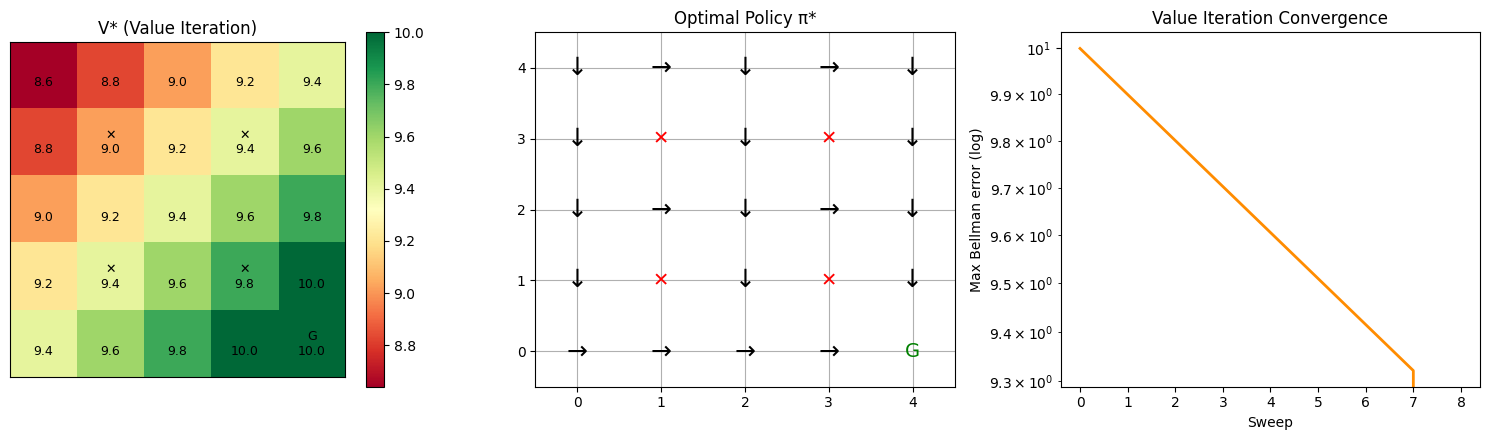

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# Value function
im = axes[0].imshow(V_star.reshape(5,5), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for s in range(25):
    r,c=divmod(s,5)
    label='G' if (r,c)==env.goal else ('✕' if (r,c) in env.pits else '')
    axes[0].text(c,r,f'{label}\n{V_star[s]:.1f}',ha='center',va='center',fontsize=9)
axes[0].set_title('V* (Value Iteration)'); axes[0].set_xticks([]); axes[0].set_yticks([])

# Optimal policy
axes[1].set_xlim(-0.5,4.5); axes[1].set_ylim(-0.5,4.5)
axes[1].set_xticks(range(5)); axes[1].set_yticks(range(5)); axes[1].grid(True)
for s in range(25):
    r,c=divmod(s,5)
    if (r,c)==env.goal:         axes[1].text(c,4-r,'G',ha='center',va='center',fontsize=14,color='green')
    elif (r,c) in env.pits:     axes[1].text(c,4-r,'✕',ha='center',va='center',fontsize=14,color='red')
    else:                       axes[1].text(c,4-r,env.ACTION_SYMBOLS[pi_star[s]],ha='center',va='center',fontsize=18)
axes[1].set_title('Optimal Policy π*')

# Convergence
axes[2].semilogy(errors, color='darkorange', linewidth=2)
axes[2].set_xlabel('Sweep'); axes[2].set_ylabel('Max Bellman error (log)')
axes[2].set_title('Value Iteration Convergence')
plt.tight_layout(); plt.show()

## Policy Iteration vs Value Iteration — Comparison

In [5]:
import time

# Time value iteration
t0 = time.time()
for _ in range(20): value_iteration(env)
vi_time = (time.time()-t0)/20

print(f"Value Iteration avg time: {vi_time*1000:.2f} ms")
print(f"\nKey difference:")
print(" Policy Iteration: full eval to convergence at each step (many inner loops)")
print(" Value Iteration:  single sweep per iteration (simpler inner loop)")
print(" Both converge to the same optimal policy.")

Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 sweeps (Δ=0.00e+00)
Value iteration converged in 9 

## ✅ Exercises
1. Plot V* as a 3D surface using `ax.plot_surface`. Does the shape make intuitive sense?
2. Set γ=0.5. Does value iteration still converge? What does the optimal policy look like now?
3. **Challenge**: implement **asynchronous value iteration** — update one randomly-chosen state per step. Plot the convergence and compare to synchronous.

### Exercise 2: Value Iteration with $\gamma = 0.5$

* **Does it converge?** Yes, it actually converges *faster* (in fewer sweeps). Since $\gamma$ is small, distant rewards are heavily discounted and quickly approach zero, meaning the Bellman error drops below the threshold $\theta$ very quickly.
* **What does the optimal policy look like?** Because the agent is incredibly short-sighted, states far away from the goal lose the "pull" of the +10 reward. For states near the pits, the immediate -0.1 step cost or the distant +10 reward isn't enough to overcome the risk of moving. The policy becomes overly cautious or erratic far from the goal because the gradient of the value function becomes extremely flat.

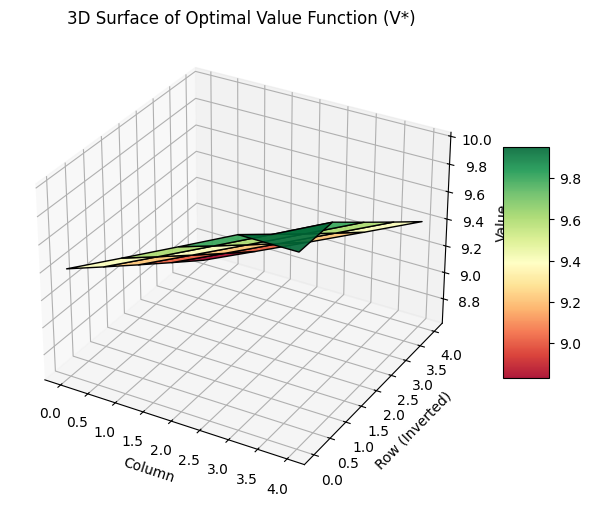

Observation: The shape makes perfect intuitive sense. It peaks sharply at the goal (4,4) and dips into deep valleys around the pits.

--- Running Asynchronous Value Iteration ---


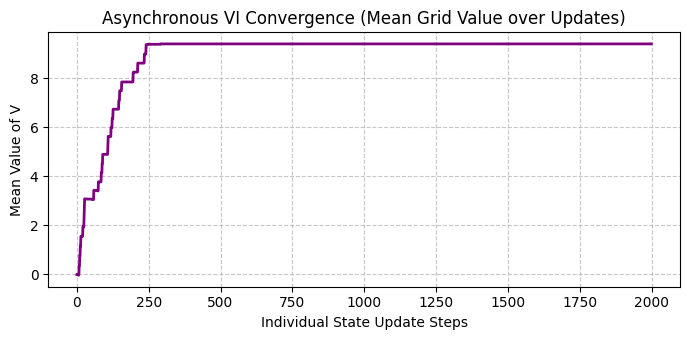

Conclusion: Asynchronous VI is messy but effective. It converges without requiring strict ordered sweeps, which is crucial for massive state spaces where full sweeps are computationally impossible.


In [6]:
# ==========================================
# Exercise 1: 3D Surface Plot of V*
# ==========================================
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

# Create coordinate meshgrid
x = np.arange(5)
y = np.arange(5)
X, Y = np.meshgrid(x, y)
# Note: Reshaping and flipping Y so the visualization matches the 2D layout intuitively
Z = V_star.reshape(5, 5)[::-1, :]

surf = ax.plot_surface(X, Y, Z, cmap='RdYlGn', edgecolor='k', alpha=0.9)
ax.set_title("3D Surface of Optimal Value Function (V*)")
ax.set_xlabel("Column")
ax.set_ylabel("Row (Inverted)")
ax.set_zlabel("Value")
fig.colorbar(surf, shrink=0.5, aspect=5)
plt.show()
print("Observation: The shape makes perfect intuitive sense. It peaks sharply at the goal (4,4) and dips into deep valleys around the pits.")

# ==========================================
# Exercise 3: Challenge - Asynchronous Value Iteration
# ==========================================
def async_value_iteration(env, gamma=0.99, n_steps=2000):
    """Updates one randomly chosen state per step instead of sweeping the whole grid."""
    V = np.zeros(env.n_states())
    history = []

    for _ in range(n_steps):
        # Pick a random state
        s = np.random.randint(env.n_states())

        # Calculate max Q value just for this state
        Q_s = [sum(p*(r + (0 if d else gamma*V[ns]))
                   for p,ns,r,d in env.transitions(s,a))
               for a in range(env.n_actions())]

        # In-place update
        V[s] = max(Q_s)

        # Log the average value to track convergence over time
        history.append(np.mean(V))

    return V, history

print("\n--- Running Asynchronous Value Iteration ---")
V_async, async_hist = async_value_iteration(env)

plt.figure(figsize=(7, 3.5))
plt.plot(async_hist, color='purple', linewidth=2)
plt.title("Asynchronous VI Convergence (Mean Grid Value over Updates)")
plt.xlabel("Individual State Update Steps")
plt.ylabel("Mean Value of V")
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Conclusion: Asynchronous VI is messy but effective. It converges without requiring strict ordered sweeps, which is crucial for massive state spaces where full sweeps are computationally impossible.")